In [1]:
import tenseal as ts
import numpy as np
import time
import pandas as pd

from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report

# Small Random Dataset - 100 samples

Make classification samples and perform train and test split

In [2]:
sd_x, sd_y = make_classification(n_samples=100, class_sep=2, n_features=30, random_state=42)
print("X Minimum: ", sd_x.min())
print("X Maximum: ", sd_x.max())

sd_x_train, sd_x_test, sd_y_train, sd_y_test = train_test_split(sd_x, sd_y, test_size=0.1, random_state=42)

X Minimum:  -3.8192253511146537
X Maximum:  3.625093656245981


Perform Standard Scaler on train and test sets

In [3]:
sd_scaler = StandardScaler()
sd_x_train = sd_scaler.fit_transform(sd_x_train)
sd_x_test = sd_scaler.transform(sd_x_test)

sd_y_train = sd_y_train.reshape(-1, 1)
sd_y_test = sd_y_test.reshape(-1, 1)

Evaluate number of training and testing samples from train/test split

In [4]:
sd_num_x_training = len(sd_x_train)
sd_num_x_test = len(sd_x_test)
sd_num_y_training = len(sd_y_train)
sd_num_y_test = len(sd_y_test)

print("Number of x training: ", sd_num_x_training)
print("Number of x test: ", sd_num_x_test)
print("Number of y training: ", sd_num_y_training)
print("Number of y test: ", sd_num_y_test)

Number of x training:  90
Number of x test:  10
Number of y training:  90
Number of y test:  10


In [5]:
print("sd_x_train shape: ", sd_x_train.shape)
print("sd_x_test shape: ", sd_x_test.shape)
print("sd_y_train shape: ", sd_y_train.shape)
print("sd_y_test shape: ", sd_y_train.shape) 

sd_x_train shape:  (90, 30)
sd_x_test shape:  (10, 30)
sd_y_train shape:  (90, 1)
sd_y_test shape:  (90, 1)


Initialise Model and Perform Fitting and Prediction

In [6]:
sd_total_start_time = time.time()

sd_model = LogisticRegression()

sd_ml_start_time = time.time()

sd_model.fit(sd_x_train, sd_y_train)
sd_y_pred_clear = sd_model.predict(sd_x_test)

sd_ml_end_time = time.time()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Evaluate accuracy performed on the cleartext during prediction

In [7]:
sd_clear_accuracy = accuracy_score(sd_y_test, sd_y_pred_clear)
sd_clear_precision = precision_score(sd_y_test, sd_y_pred_clear)
sd_clear_recall = recall_score (sd_y_test, sd_y_pred_clear)
sd_clear_f1 = f1_score(sd_y_test, sd_y_pred_clear)
sd_clear_auc = roc_auc_score(sd_y_test, sd_y_pred_clear)
sd_ml_elapsed_time = sd_ml_end_time - sd_ml_start_time

print("Cleartext Accuracy Score: ", sd_clear_accuracy)
print("Cleartext Precision Score: ", sd_clear_precision)
print("Cleartext Recall Score: ", sd_clear_recall)
print("Cleartext F1 Score: ", sd_clear_f1)
print("Cleartext AUC Score: ", sd_clear_auc)
print(f"Time it took for ML to make predictions: {sd_ml_elapsed_time:.5f} seconds")

Cleartext Accuracy Score:  1.0
Cleartext Precision Score:  1.0
Cleartext Recall Score:  1.0
Cleartext F1 Score:  1.0
Cleartext AUC Score:  1.0
Time it took for ML to make predictions: 0.00984 seconds


Confusion Matrix - Cleartext

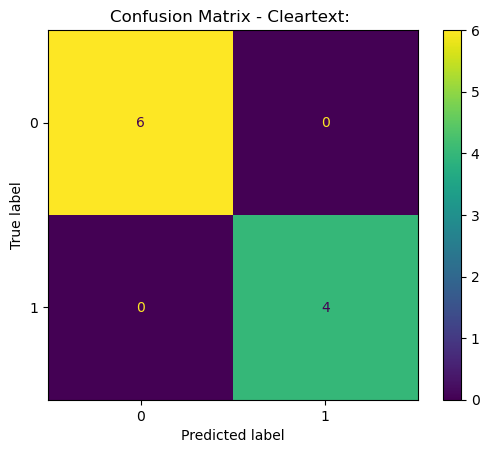

In [8]:
sd_clear_cm = metrics.confusion_matrix(sd_y_test, sd_y_pred_clear)
sd_clear_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=sd_clear_cm)
sd_clear_disp.plot()
plt.title("Confusion Matrix - Cleartext: ")
plt.show()

Classification Report - Cleartext

In [9]:
print("Classification Report - Cleartext: ")
print(classification_report(sd_y_test, sd_y_pred_clear))

Classification Report - Cleartext: 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



Set up the TenSEAL Context

In [10]:
sd_poly_mod_degree = 8192
sd_coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]

sd_ctx = ts.context(ts.SCHEME_TYPE.CKKS, sd_poly_mod_degree, -1, sd_coeff_mod_bit_sizes)
sd_ctx.global_scale = 2 ** 21
sd_ctx.generate_galois_keys()

Epoch-Based Encrypted Training Loop

In [11]:
sd_fhe_prediction_start_time = time.time()

sd_weights = sd_model.coef_.flatten()
sd_bias = sd_model.intercept_[0]

SD_EPOCHS = 10
SD_LEARNING_RATE = 0.05

for epoch in range(SD_EPOCHS):
    delta_w = np.zeros_like(sd_weights)
    delta_b = 0

    for i in range(len(sd_x_train)):
        x = sd_x_train[i].tolist()
        y = sd_y_train[i][0]

        enc_x = ts.ckks_vector(sd_ctx, x)
        enc_w = ts.ckks_vector(sd_ctx, sd_weights.tolist())
        enc_b = ts.ckks_vector(sd_ctx, [sd_bias])

        enc_out = enc_x.dot(enc_w) + enc_b
        enc_prob = enc_out.polyval([0.5, 0.197, 0, -0.004])
        prob = enc_prob.decrypt()[0]
        prob = min(max(prob, 0), 1)

        error = prob - y
        delta_w += error * np.array(x)
        delta_b += error

    REGULARIZATION = 0.05
    sd_weights -= SD_LEARNING_RATE * ((delta_w / len(sd_x_train)) + REGULARIZATION * sd_weights)
    sd_bias -= SD_LEARNING_RATE * (delta_b / len(sd_x_train))

    print(f"Epoch {epoch+1} completed.")

Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.


Encrypted Prediction After Training

In [12]:
sd_y_pred_encrypted = []

for i in range(len(sd_x_test)):
    x = sd_x_test[i].tolist()
    enc_x = ts.ckks_vector(sd_ctx, x)
    enc_w = ts.ckks_vector(sd_ctx, sd_weights)
    enc_b = ts.ckks_vector(sd_ctx, [sd_bias])
    
    enc_out = enc_x.dot(enc_w) + enc_b
    enc_prob = enc_out.polyval([0.5, 0.197, 0, -0.004])
    prob = enc_prob.decrypt()[0]
    prob = min(max(prob, 0), 1)
    
    pred = 1 if prob >= 0.5 else 0
    sd_y_pred_encrypted.append(pred)
    
sd_y_pred_encrypted = np.array(sd_y_pred_encrypted).reshape(-1, 1)

sd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [13]:
sd_fhe_accuracy = accuracy_score(sd_y_test, sd_y_pred_encrypted)
sd_fhe_precision = precision_score(sd_y_test, sd_y_pred_encrypted)
sd_fhe_recall = recall_score (sd_y_test, sd_y_pred_encrypted)
sd_fhe_f1 = f1_score(sd_y_test, sd_y_pred_encrypted)
sd_fhe_auc = roc_auc_score(sd_y_test, sd_y_pred_encrypted)
sd_fhe_prediction_elapsed_time = sd_fhe_prediction_end_time - sd_fhe_prediction_start_time

print("FHE Accuracy Score: ", sd_fhe_accuracy)
print("FHE Precision Score: ", sd_fhe_precision)
print("FHE Recall Score: ", sd_fhe_recall)
print("FHE F1 Score: ", sd_fhe_f1)
print("FHE AUC Score: ", sd_fhe_auc)
print(f"Total time for FHE Execution and Evaluation: {sd_fhe_prediction_elapsed_time:.5f} seconds")

FHE Accuracy Score:  0.4
FHE Precision Score:  0.0
FHE Recall Score:  0.0
FHE F1 Score:  0.0
FHE AUC Score:  0.33333333333333337
Total time for FHE Execution and Evaluation: 58.82393 seconds


Confusion Matrix - FHE

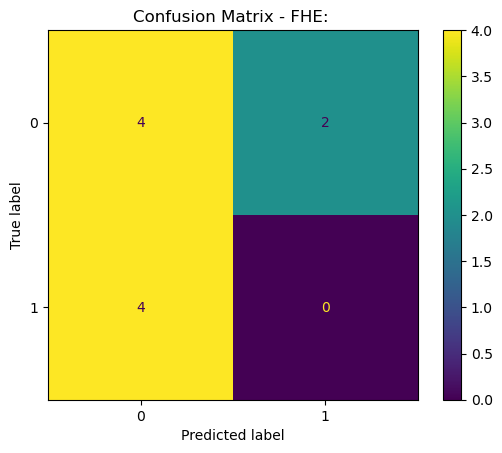

In [14]:
sd_encrypted_cm = metrics.confusion_matrix(sd_y_test, sd_y_pred_encrypted)
sd_encrypted_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=sd_encrypted_cm)
sd_encrypted_disp.plot()
plt.title("Confusion Matrix - FHE: ")
plt.show()

Classification Report - FHE

In [15]:
print("Classification Report - FHE: ")
print(classification_report(sd_y_test, sd_y_pred_encrypted))

Classification Report - FHE: 
              precision    recall  f1-score   support

           0       0.50      0.67      0.57         6
           1       0.00      0.00      0.00         4

    accuracy                           0.40        10
   macro avg       0.25      0.33      0.29        10
weighted avg       0.30      0.40      0.34        10



Evaluation of Model

In [16]:
sd_y_pred_cleartext_flat = sd_y_pred_clear.ravel()
sd_y_pred_encrypted_flat = sd_y_pred_encrypted.ravel()
sd_y_test_flat = sd_y_test.ravel()

sd_comparison_df = pd.DataFrame({
    "Index": np.arange(len(sd_y_test)),
    "Cleartext Prediction": sd_y_pred_cleartext_flat,
    "Encrypted Prediction": sd_y_pred_encrypted_flat,
    "True Label": sd_y_test_flat
})

print("Per-sample Comparison:")
display(sd_comparison_df)

sd_total_end_time = time.time()
sd_total_elapsed_time = sd_total_end_time - sd_total_start_time
print(f"Total time for Model's to Run: {sd_total_elapsed_time:.5f} seconds")

Per-sample Comparison:


,Index,Cleartext Prediction,Encrypted Prediction,True Label
0,0,0,0,0
1,1,0,1,0
2,2,0,1,0
3,3,0,0,0
4,4,1,0,1
5,5,0,0,0
6,6,1,0,1
7,7,0,0,0
8,8,1,0,1
9,9,1,0,1


Total time for Model's to Run: 59.46038 seconds


# Medium Random Dataset - 1000 samples

Make classification samples and perform train and test split

In [17]:
md_x, md_y = make_classification(n_samples=1000, class_sep=2, n_features=30, random_state=42)
print("X Minimum: ", md_x.min())
print("X Maximum: ", md_x.max())

md_x_train, md_x_test, md_y_train, md_y_test = train_test_split(md_x, md_y, test_size=0.1, random_state=42)

X Minimum:  -5.543441462057407
X Maximum:  5.020261576429226


Perform Standard Scaler on train and test sets

In [18]:
md_scaler = StandardScaler()
md_x_train = md_scaler.fit_transform(md_x_train)
md_x_test = md_scaler.transform(md_x_test)

md_y_train = md_y_train.reshape(-1, 1)
md_y_test = md_y_test.reshape(-1, 1)

Evaluate number of training and testing samples from train/test split

In [19]:
md_num_x_training = len(md_x_train)
md_num_x_test = len(md_x_test)
md_num_y_training = len(md_y_train)
md_num_y_test = len(md_y_test)

print("Number of x training: ", md_num_x_training)
print("Number of x test: ", md_num_x_test)
print("Number of y training: ", md_num_y_training)
print("Number of y test: ", md_num_y_test)

Number of x training:  900
Number of x test:  100
Number of y training:  900
Number of y test:  100


In [20]:
print("md_x_train shape: ", md_x_train.shape)
print("md_x_test shape: ", md_x_test.shape)
print("md_y_train shape: ", md_y_train.shape)
print("md_y_test shape: ", md_y_train.shape)

md_x_train shape:  (900, 30)
md_x_test shape:  (100, 30)
md_y_train shape:  (900, 1)
md_y_test shape:  (900, 1)


Initialise and Perform Fitting and Prediction

In [21]:
md_total_start_time = time.time()

md_model = LogisticRegression()

md_ml_start_time = time.time()

md_model.fit(md_x_train, md_y_train)
md_y_pred_clear = md_model.predict(md_x_test)

md_ml_end_time = time.time()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Evaluate accuracy performed on the cleartext during prediction

In [22]:
md_clear_accuracy = accuracy_score(md_y_test, md_y_pred_clear)
md_clear_precision = precision_score(md_y_test, md_y_pred_clear)
md_clear_recall = recall_score (md_y_test, md_y_pred_clear)
md_clear_f1 = f1_score(md_y_test, md_y_pred_clear)
md_clear_auc = roc_auc_score(md_y_test, md_y_pred_clear)
md_ml_elapsed_time = md_ml_end_time - md_ml_start_time

print("Cleartext Accuracy Score: ", md_clear_accuracy)
print("Cleartext Precision Score: ", md_clear_precision)
print("Cleartext Recall Score: ", md_clear_recall)
print("Cleartext F1 Score: ", md_clear_f1)
print("Cleartext AUC Score: ", md_clear_auc)
print(f"Time it took for ML to make predictions: {md_ml_elapsed_time:.5f} seconds")

Cleartext Accuracy Score:  0.97
Cleartext Precision Score:  1.0
Cleartext Recall Score:  0.9375
Cleartext F1 Score:  0.967741935483871
Cleartext AUC Score:  0.96875
Time it took for ML to make predictions: 0.06200 seconds


Confusion Matrix - Cleartext

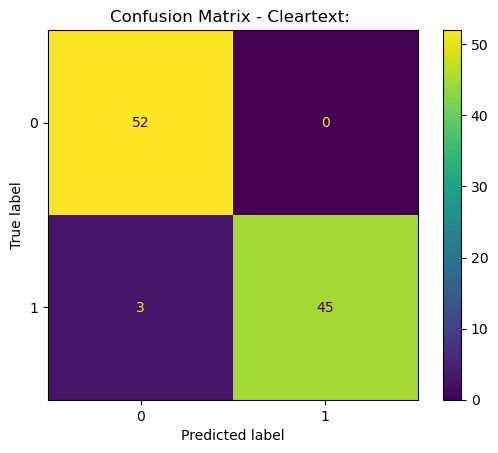

In [23]:
md_clear_cm = metrics.confusion_matrix(md_y_test, md_y_pred_clear)
md_clear_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=md_clear_cm)
md_clear_disp.plot()
plt.title("Confusion Matrix - Cleartext: ")
plt.show()

Classification Report - Cleartext

In [24]:
print("Classification Report - Cleartext: ")
print(classification_report(md_y_test, md_y_pred_clear))

Classification Report - Cleartext: 
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        52
           1       1.00      0.94      0.97        48

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



Set up the TenSEAL Context

In [25]:
md_poly_mod_degree = 8192
md_coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]

md_ctx = ts.context(ts.SCHEME_TYPE.CKKS, md_poly_mod_degree, -1, md_coeff_mod_bit_sizes)
md_ctx.global_scale = 2 ** 21
md_ctx.generate_galois_keys()

Epoch-Based Encrypted Training Loop

In [26]:
md_fhe_prediction_start_time = time.time()

md_weights = md_model.coef_.flatten()
md_bias = md_model.intercept_[0]

MD_EPOCHS = 10
MD_LEARNING_RATE = 0.05

for epoch in range(MD_EPOCHS):
    delta_w = np.zeros_like(md_weights)
    delta_b = 0

    for i in range(len(md_x_train)):
        x = md_x_train[i].tolist()
        y = md_y_train[i][0]

        enc_x = ts.ckks_vector(md_ctx, x)
        enc_w = ts.ckks_vector(md_ctx, md_weights.tolist())
        enc_b = ts.ckks_vector(md_ctx, [md_bias])

        enc_out = enc_x.dot(enc_w) + enc_b
        enc_prob = enc_out.polyval([0.5, 0.197, 0, -0.004])
        prob = enc_prob.decrypt()[0]
        prob = min(max(prob, 0), 1)

        error = prob - y
        delta_w += error * np.array(x)
        delta_b += error

    REGULARIZATION = 0.05
    md_weights -= MD_LEARNING_RATE * ((delta_w / len(md_x_train)) + REGULARIZATION * md_weights)
    md_bias -= MD_LEARNING_RATE * (delta_b / len(md_x_train))

    print(f"Epoch {epoch+1} completed.")

Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.


Encrypted Prediction After Training

In [27]:
md_y_pred_encrypted = []

for i in range(len(md_x_test)):
    x = md_x_test[i].tolist()
    enc_x = ts.ckks_vector(md_ctx, x)
    enc_w = ts.ckks_vector(md_ctx, md_weights)
    enc_b = ts.ckks_vector(md_ctx, [md_bias])
    
    enc_out = enc_x.dot(enc_w) + enc_b
    enc_prob = enc_out.polyval([0.5, 0.197, 0, -0.004])
    prob = enc_prob.decrypt()[0]
    prob = min(max(prob, 0), 1)
    
    pred = 1 if prob >= 0.5 else 0
    md_y_pred_encrypted.append(pred)
    
md_y_pred_encrypted = np.array(md_y_pred_encrypted).reshape(-1, 1)

md_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [28]:
md_fhe_accuracy = accuracy_score(md_y_test, md_y_pred_encrypted)
md_fhe_precision = precision_score(md_y_test, md_y_pred_encrypted)
md_fhe_recall = recall_score (md_y_test, md_y_pred_encrypted)
md_fhe_f1 = f1_score(md_y_test, md_y_pred_encrypted)
md_fhe_auc = roc_auc_score(md_y_test, md_y_pred_encrypted)
md_fhe_prediction_elapsed_time = md_fhe_prediction_end_time - md_fhe_prediction_start_time

print("FHE Accuracy Score: ", md_fhe_accuracy)
print("FHE Precision Score: ", md_fhe_precision)
print("FHE Recall Score: ", md_fhe_recall)
print("FHE F1 Score: ", md_fhe_f1)
print("FHE AUC Score: ", md_fhe_auc)
print(f"Total time for FHE Execution and Evaluation: {md_fhe_prediction_elapsed_time:.5f} seconds")

FHE Accuracy Score:  0.82
FHE Precision Score:  0.8947368421052632
FHE Recall Score:  0.7083333333333334
FHE F1 Score:  0.7906976744186046
FHE AUC Score:  0.8157051282051283
Total time for FHE Execution and Evaluation: 592.85786 seconds


Confusion Matrix - FHE

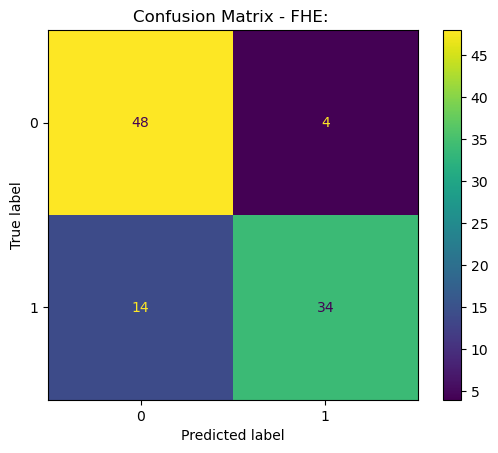

In [29]:
md_encrypted_cm = metrics.confusion_matrix(md_y_test, md_y_pred_encrypted)
md_encrypted_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=md_encrypted_cm)
md_encrypted_disp.plot()
plt.title("Confusion Matrix - FHE: ")
plt.show()

Classification Report - FHE

In [30]:
print("Classification Report - FHE: ")
print(classification_report(md_y_test, md_y_pred_encrypted))

Classification Report - FHE: 
              precision    recall  f1-score   support

           0       0.77      0.92      0.84        52
           1       0.89      0.71      0.79        48

    accuracy                           0.82       100
   macro avg       0.83      0.82      0.82       100
weighted avg       0.83      0.82      0.82       100



Evaluation of Model

In [31]:
md_y_pred_cleartext_flat = md_y_pred_clear.ravel()
md_y_pred_encrypted_flat = md_y_pred_encrypted.ravel()
md_y_test_flat = md_y_test.ravel()

md_comparison_df = pd.DataFrame({
    "Index": np.arange(len(md_y_test)),
    "Cleartext Prediction": md_y_pred_cleartext_flat,
    "Encrypted Prediction": md_y_pred_encrypted_flat,
    "True Label": md_y_test_flat
})

print("Per-sample Comparison:")
display(md_comparison_df)

md_total_end_time = time.time()
md_total_elapsed_time = md_total_end_time - md_total_start_time
print(f"Total time for Model's to Run: {md_total_elapsed_time:.5f} seconds")

Per-sample Comparison:


,Index,Cleartext Prediction,Encrypted Prediction,True Label
0,0,0,1,0
1,1,0,0,0
2,2,0,0,0
3,3,1,0,1
4,4,1,1,1
...,...,...,...,...
95,95,0,0,0
96,96,0,0,0
97,97,1,1,1
98,98,0,0,0


Total time for Model's to Run: 593.56689 seconds


# Large Random Dataset - 10,000 samples

Make classification samples and perform train and test split

In [32]:
ld_x, ld_y = make_classification(n_samples=10000, class_sep=2, n_features=30, random_state=42)
print("X Minimum: ", ld_x.min())
print("X Maximum: ", ld_x.max())

ld_x_train, ld_x_test, ld_y_train, ld_y_test = train_test_split(ld_x, ld_y, test_size=0.1, random_state=42)

X Minimum:  -6.049090666105036
X Maximum:  6.765510169350037


Perform Standard Scaler on train and test sets

In [33]:
ld_scaler = StandardScaler()
ld_x_train = ld_scaler.fit_transform(ld_x_train)
ld_x_test = ld_scaler.transform(ld_x_test)

ld_y_train = ld_y_train.reshape(-1, 1)
ld_y_test = ld_y_test.reshape(-1, 1)

Evaluate number of training and testing samples from train/test split

In [34]:
ld_num_x_training = len(ld_x_train)
ld_num_x_test = len(ld_x_test)
ld_num_y_training = len(ld_y_train)
ld_num_y_test = len(ld_y_test)

print("Number of x training: ", ld_num_x_training)
print("Number of x test: ", ld_num_x_test)
print("Number of y training: ", ld_num_y_training)
print("Number of y test: ", ld_num_y_test)

Number of x training:  9000
Number of x test:  1000
Number of y training:  9000
Number of y test:  1000


In [35]:
print("ld_x_train shape: ", ld_x_train.shape)
print("ld_x_test shape: ", ld_x_test.shape)
print("ld_y_train shape: ", ld_y_train.shape)
print("ld_y_test shape: ", ld_y_train.shape) 

ld_x_train shape:  (9000, 30)
ld_x_test shape:  (1000, 30)
ld_y_train shape:  (9000, 1)
ld_y_test shape:  (9000, 1)


Initialise Model and Perform Fitting and Prediction

In [36]:
ld_total_start_time = time.time()

ld_model = LogisticRegression()

ld_ml_start_time = time.time()

ld_model.fit(ld_x_train, ld_y_train)
ld_y_pred_clear = ld_model.predict(ld_x_test)

ld_ml_end_time = time.time()

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Evaluate accuracy performed on the cleartext during prediction

In [37]:
ld_clear_accuracy = accuracy_score(ld_y_test, ld_y_pred_clear)
ld_clear_precision = precision_score(ld_y_test, ld_y_pred_clear)
ld_clear_recall = recall_score (ld_y_test, ld_y_pred_clear)
ld_clear_f1 = f1_score(ld_y_test, ld_y_pred_clear)
ld_clear_auc = roc_auc_score(ld_y_test, ld_y_pred_clear)
ld_ml_elapsed_time = ld_ml_end_time - ld_ml_start_time

print("Cleartext Accuracy Score: ", ld_clear_accuracy)
print("Cleartext Precision Score: ", ld_clear_precision)
print("Cleartext Recall Score: ", ld_clear_recall)
print("Cleartext F1 Score: ", ld_clear_f1)
print("Cleartext AUC Score: ", ld_clear_auc)
print(f"Time it took for ML to make predictions: {ld_ml_elapsed_time:.5f} seconds")

Cleartext Accuracy Score:  0.98
Cleartext Precision Score:  0.9794661190965093
Cleartext Recall Score:  0.9794661190965093
Cleartext F1 Score:  0.9794661190965093
Cleartext AUC Score:  0.9799864708542975
Time it took for ML to make predictions: 0.05418 seconds


Confusion Matrix - Cleartext

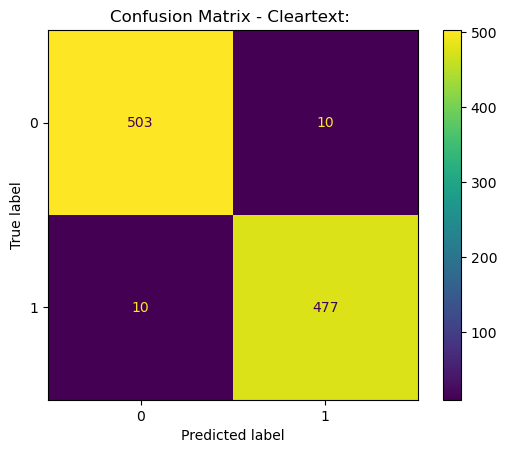

In [38]:
ld_clear_cm = metrics.confusion_matrix(ld_y_test, ld_y_pred_clear)
ld_clear_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=ld_clear_cm)
ld_clear_disp.plot()
plt.title("Confusion Matrix - Cleartext: ")
plt.show()

Classification Report - Cleartext

In [39]:
print("Classification Report - Cleartext: ")
print(classification_report(ld_y_test, ld_y_pred_clear))

Classification Report - Cleartext: 
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       513
           1       0.98      0.98      0.98       487

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000



Set up the TenSEAL Context

In [40]:
ld_poly_mod_degree = 8192
ld_coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]

ld_ctx = ts.context(ts.SCHEME_TYPE.CKKS, ld_poly_mod_degree, -1, ld_coeff_mod_bit_sizes)
ld_ctx.global_scale = 2 ** 21
ld_ctx.generate_galois_keys()

Epoch-Based Encrypted Training Loop

In [41]:
ld_fhe_prediction_start_time = time.time()

ld_weights = ld_model.coef_.flatten()
ld_bias = ld_model.intercept_[0]

LD_EPOCHS = 10
LD_LEARNING_RATE = 0.05

for epoch in range(LD_EPOCHS):
    delta_w = np.zeros_like(ld_weights)
    delta_b = 0

    for i in range(len(ld_x_train)):
        x = ld_x_train[i].tolist()
        y = ld_y_train[i][0]

        enc_x = ts.ckks_vector(ld_ctx, x)
        enc_w = ts.ckks_vector(ld_ctx, ld_weights.tolist())
        enc_b = ts.ckks_vector(ld_ctx, [ld_bias])

        enc_out = enc_x.dot(enc_w) + enc_b
        enc_prob = enc_out.polyval([0.5, 0.197, 0, -0.004])
        prob = enc_prob.decrypt()[0]
        prob = min(max(prob, 0), 1)

        error = prob - y
        delta_w += error * np.array(x)
        delta_b += error

    REGULARIZATION = 0.05
    ld_weights -= LD_LEARNING_RATE * ((delta_w / len(ld_x_train)) + REGULARIZATION * ld_weights)
    ld_bias -= LD_LEARNING_RATE * (delta_b / len(ld_x_train))

    print(f"Epoch {epoch+1} completed.")

Epoch 1 completed.
Epoch 2 completed.
Epoch 3 completed.
Epoch 4 completed.
Epoch 5 completed.
Epoch 6 completed.
Epoch 7 completed.
Epoch 8 completed.
Epoch 9 completed.
Epoch 10 completed.


Encrypted Prediction After Training

In [42]:
ld_y_pred_encrypted = []

for i in range(len(ld_x_test)):
    x = ld_x_test[i].tolist()
    enc_x = ts.ckks_vector(ld_ctx, x)
    enc_w = ts.ckks_vector(ld_ctx, ld_weights)
    enc_b = ts.ckks_vector(ld_ctx, [ld_bias])
    
    enc_out = enc_x.dot(enc_w) + enc_b
    enc_prob = enc_out.polyval([0.5, 0.197, 0, -0.004])
    prob = enc_prob.decrypt()[0]
    prob = min(max(prob, 0), 1)
    
    pred = 1 if prob >= 0.5 else 0
    ld_y_pred_encrypted.append(pred)
    
ld_y_pred_encrypted = np.array(ld_y_pred_encrypted).reshape(-1, 1)

ld_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [43]:
ld_fhe_accuracy = accuracy_score(ld_y_test, ld_y_pred_encrypted)
ld_fhe_precision = precision_score(ld_y_test, ld_y_pred_encrypted)
ld_fhe_recall = recall_score (ld_y_test, ld_y_pred_encrypted)
ld_fhe_f1 = f1_score(ld_y_test, ld_y_pred_encrypted)
ld_fhe_auc = roc_auc_score(ld_y_test, ld_y_pred_encrypted)
ld_fhe_prediction_elapsed_time = ld_fhe_prediction_end_time - ld_fhe_prediction_start_time

print("FHE Accuracy Score: ", ld_fhe_accuracy)
print("FHE Precision Score: ", ld_fhe_precision)
print("FHE Recall Score: ", ld_fhe_recall)
print("FHE F1 Score: ", ld_fhe_f1)
print("FHE AUC Score: ", ld_fhe_auc)
print(f"Total time for FHE Execution and Evaluation: {ld_fhe_prediction_elapsed_time:.5f} seconds")

FHE Accuracy Score:  0.352
FHE Precision Score:  0.401468788249694
FHE Recall Score:  0.6735112936344969
FHE F1 Score:  0.5030674846625767
FHE AUC Score:  0.36014745968274553
Total time for FHE Execution and Evaluation: 7670.78640 seconds


Confusion Matrix - FHE

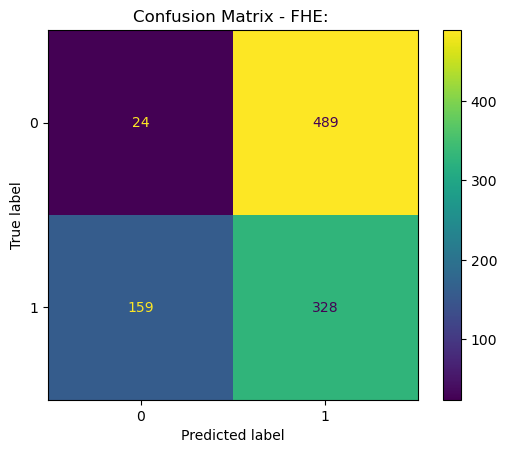

In [44]:
ld_encrypted_cm = metrics.confusion_matrix(ld_y_test, ld_y_pred_encrypted)
ld_encrypted_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=ld_encrypted_cm)
ld_encrypted_disp.plot()
plt.title("Confusion Matrix - FHE: ")
plt.show()

Classification Report - FHE

In [45]:
print("Classification Report - FHE: ")
print(classification_report(ld_y_test, ld_y_pred_encrypted))

Classification Report - FHE: 
              precision    recall  f1-score   support

           0       0.13      0.05      0.07       513
           1       0.40      0.67      0.50       487

    accuracy                           0.35      1000
   macro avg       0.27      0.36      0.29      1000
weighted avg       0.26      0.35      0.28      1000



Evaluation of Model

In [46]:
ld_y_pred_cleartext_flat = ld_y_pred_clear.ravel()
ld_y_pred_encrypted_flat = ld_y_pred_encrypted.ravel()
ld_y_test_flat = ld_y_test.ravel()

ld_comparison_df = pd.DataFrame({
    "Index": np.arange(len(ld_y_test)),
    "Cleartext Prediction": ld_y_pred_cleartext_flat,
    "Encrypted Prediction": ld_y_pred_encrypted_flat,
    "True Label": ld_y_test_flat
})

print("Per-sample Comparison:")
display(ld_comparison_df)

ld_total_end_time = time.time()
ld_total_elapsed_time = ld_total_end_time - ld_total_start_time
print(f"Total time for Model's to Run: {ld_total_elapsed_time:.5f} seconds")

Per-sample Comparison:


,Index,Cleartext Prediction,Encrypted Prediction,True Label
0,0,0,1,0
1,1,1,1,1
2,2,1,1,1
3,3,0,0,1
4,4,1,0,1
...,...,...,...,...
995,995,0,1,0
996,996,0,1,0
997,997,1,1,1
998,998,0,1,0


Total time for Model's to Run: 7671.45521 seconds


# High Random Dataset - 100,000 samples

Make classification samples and perform train and test split

In [47]:
# hd_x, hd_y = make_classification(n_samples=100000, class_sep=2, n_features=30, random_state=42)
# print("X Minimum: ", hd_x.min())
# print("X Maximum: ", hd_x.max())

# hd_x_train, hd_x_test, hd_y_train, hd_y_test = train_test_split(hd_x, hd_y, test_size=0.1, random_state=42)

Perform Standard Scaler on train and test sets

In [48]:
# hd_scaler = StandardScaler()
# hd_x_train = hd_scaler.fit_transform(hd_x_train)
# hd_x_test = hd_scaler.transform(hd_x_test)

# hd_y_train = hd_y_train.reshape(-1, 1)
# hd_y_test = hd_y_test.reshape(-1, 1)

Evaluate number of training and testing samples from train/test split

In [49]:
# hd_num_x_training = len(hd_x_train)
# hd_num_x_test = len(hd_x_test)
# hd_num_y_training = len(hd_y_train)
# hd_num_y_test = len(hd_y_test)

# print("Number of x training: ", hd_num_x_training)
# print("Number of x test: ", hd_num_x_test)
# print("Number of y training: ", hd_num_y_training)
# print("Number of y test: ", hd_num_y_test)

In [50]:
# print("hd_x_train shape: ", hd_x_train.shape)
# print("hd_x_test shape: ", hd_x_test.shape)
# print("hd_y_train shape: ", hd_y_train.shape)
# print("hd_y_test shape: ", hd_y_train.shape) 

Initialise Model and Perform Fitting and Prediction

In [51]:
# hd_total_start_time = time.time()

# hd_model = LogisticRegression()

# hd_ml_start_time = time.time()

# hd_model.fit(hd_x_train, hd_y_train)
# hd_y_pred_clear = hd_model.predict(hd_x_test)

# hd_ml_end_time = time.time()

Evaluate accuracy performed on the cleartext during prediction

In [52]:
# hd_clear_accuracy = accuracy_score(hd_y_test, hd_y_pred_clear)
# hd_clear_precision = precision_score(hd_y_test, hd_y_pred_clear)
# hd_clear_recall = recall_score (hd_y_test, hd_y_pred_clear)
# hd_clear_f1 = f1_score(hd_y_test, hd_y_pred_clear)
# hd_clear_auc = roc_auc_score(hd_y_test, hd_y_pred_clear)
# hd_ml_elapsed_time = hd_ml_end_time - hd_ml_start_time

# print("Cleartext Accuracy Score: ", hd_clear_accuracy)
# print("Cleartext Precision Score: ", hd_clear_precision)
# print("Cleartext Recall Score: ", hd_clear_recall)
# print("Cleartext F1 Score: ", hd_clear_f1)
# print("Cleartext AUC Score: ", hd_clear_auc)
# print(f"Time it took for ML to make predictions: {hd_ml_elapsed_time:.5f} seconds")

Confusion Matrix - Cleartext

In [53]:
# hd_clear_cm = metrics.confusion_matrix(hd_y_test, hd_y_pred_clear)
# hd_clear_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=hd_clear_cm)
# hd_clear_disp.plot()
# plt.title("Confusion Matrix - Cleartext: ")
# plt.show()

Classification Report - Cleartext

In [54]:
# print("Classification Report - Cleartext: ")
# print(classification_report(hd_y_test, hd_y_pred_clear))

Set up the TenSEAL Context

In [55]:
# hd_poly_mod_degree = 8192
# hd_coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]

# hd_ctx = ts.context(ts.SCHEME_TYPE.CKKS, hd_poly_mod_degree, -1, hd_coeff_mod_bit_sizes)
# hd_ctx.global_scale = 2 ** 21
# hd_ctx.generate_galois_keys()

Epoch-Based Encrypted Training Loop

In [56]:
# hd_fhe_prediction_start_time = time.time()

# hd_weights = hd_model.coef_.flatten()
# hd_bias = hd_model.intercept_[0]

# HD_EPOCHS = 10
# HD_LEARNING_RATE = 0.05

# for epoch in range(HD_EPOCHS):
#     delta_w = np.zeros_like(hd_weights)
#     delta_b = 0

#     for i in range(len(hd_x_train)):
#         x = hd_x_train[i].tolist()
#         y = hd_y_train[i][0]

#         enc_x = ts.ckks_vector(hd_ctx, x)
#         enc_w = ts.ckks_vector(hd_ctx, hd_weights.tolist())
#         enc_b = ts.ckks_vector(hd_ctx, [hd_bias])

#         enc_out = enc_x.dot(enc_w) + enc_b
#         enc_prob = enc_out.polyval([0.5, 0.197, 0, -0.004])
#         prob = enc_prob.decrypt()[0]
#         prob = min(max(prob, 0), 1)

#         error = prob - y
#         delta_w += error * np.array(x)
#         delta_b += error

#     REGULARIZATION = 0.05
#     hd_weights -= HD_LEARNING_RATE * ((delta_w / len(hd_x_train)) + REGULARIZATION * hd_weights)
#     hd_bias -= HD_LEARNING_RATE * (delta_b / len(hd_x_train))

#     print(f"Epoch {epoch+1} completed.")

Encrypted Prediction After Training

In [57]:
# hd_y_pred_encrypted = []

# for i in range(len(hd_x_test)):
#     x = hd_x_test[i].tolist()
#     enc_x = ts.ckks_vector(hd_ctx, x)
#     enc_w = ts.ckks_vector(hd_ctx, hd_weights)
#     enc_b = ts.ckks_vector(hd_ctx, [hd_bias])
    
#     enc_out = enc_x.dot(enc_w) + enc_b
#     enc_prob = enc_out.polyval([0.5, 0.197, 0, -0.004])
#     prob = enc_prob.decrypt()[0]
#     prob = min(max(prob, 0), 1)
    
#     pred = 1 if prob >= 0.5 else 0
#     hd_y_pred_encrypted.append(pred)
    
# hd_y_pred_encrypted = np.array(hd_y_pred_encrypted).reshape(-1, 1)

# hd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [58]:
# hd_fhe_accuracy = accuracy_score(hd_y_test, hd_y_pred_encrypted)
# hd_fhe_precision = precision_score(hd_y_test, hd_y_pred_encrypted)
# hd_fhe_recall = recall_score (hd_y_test, hd_y_pred_encrypted)
# hd_fhe_f1 = f1_score(hd_y_test, hd_y_pred_encrypted)
# hd_fhe_auc = roc_auc_score(hd_y_test, hd_y_pred_encrypted)
# hd_fhe_prediction_elapsed_time = hd_fhe_prediction_end_time - hd_fhe_prediction_start_time

# print("FHE Accuracy Score: ", hd_fhe_accuracy)
# print("FHE Precision Score: ", hd_fhe_precision)
# print("FHE Recall Score: ", hd_fhe_recall)
# print("FHE F1 Score: ", hd_fhe_f1)
# print("FHE AUC Score: ", hd_fhe_auc)
# print(f"Total time for FHE Execution and Evaluation: {hd_fhe_prediction_elapsed_time:.5f} seconds")

Confusion Matrix - FHE

In [59]:
# hd_encrypted_cm = metrics.confusion_matrix(hd_y_test, hd_y_pred_encrypted)
# hd_encrypted_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=hd_encrypted_cm)
# hd_encrypted_disp.plot()
# plt.title("Confusion Matrix - FHE: ")
# plt.show()

Classification Report - FHE

In [60]:
# print("Classification Report - FHE: ")
# print(classification_report(hd_y_test, hd_y_pred_encrypted))

Evaluation of Model

In [61]:
# hd_y_pred_cleartext_flat = hd_y_pred_clear.ravel()
# hd_y_pred_encrypted_flat = hd_y_pred_encrypted.ravel()
# hd_y_test_flat = hd_y_test.ravel()

# hd_comparison_df = pd.DataFrame({
#     "Index": np.arange(len(hd_y_test)),
#     "Cleartext Prediction": hd_y_pred_cleartext_flat,
#     "Encrypted Prediction": hd_y_pred_encrypted_flat,
#     "True Label": hd_y_test_flat
# })

# print("Per-sample Comparison:")
# display(hd_comparison_df)

# hd_total_end_time = time.time()
# hd_total_elapsed_time = hd_total_end_time - hd_total_start_time
# print(f"Total time for Model's to Run: {hd_total_elapsed_time:.5f} seconds")

# Mega Random Dataset - 1,000,000 samples

Make classification samples and perform train and test split

In [62]:
# bd_x, bd_y = make_classification(n_samples=1000000, class_sep=2, n_features=30, random_state=42)
# print("X Minimum: ", bd_x.min())
# print("X Maximum: ", bd_x.max())

# bd_x_train, bd_x_test, bd_y_train, bd_y_test = train_test_split(bd_x, bd_y, test_size=0.1, random_state=42)

Perform Standard Scaler on train and test sets

In [63]:
# bd_scaler = StandardScaler()
# bd_x_train = bd_scaler.fit_transform(bd_x_train)
# bd_x_test = bd_scaler.transform(bd_x_test)

# bd_y_train = bd_y_train.reshape(-1, 1)
# bd_y_test = bd_y_test.reshape(-1, 1)

Evaluate number of training and testing samples from train/test split

In [64]:
# bd_num_x_training = len(bd_x_train)
# bd_num_x_test = len(bd_x_test)
# bd_num_y_training = len(bd_y_train)
# bd_num_y_test = len(bd_y_test)

# print("Number of x training: ", bd_num_x_training)
# print("Number of x test: ", bd_num_x_test)
# print("Number of y training: ", bd_num_y_training)
# print("Number of y test: ", bd_num_y_test)

In [65]:
# print("bd_x_train shape: ", bd_x_train.shape)
# print("bd_x_test shape: ", bd_x_test.shape)
# print("bd_y_train shape: ", bd_y_train.shape)
# print("bd_y_test shape: ", bd_y_train.shape) 

Initialise Model and Perform Fitting and Prediction

In [66]:
# bd_total_start_time = time.time()

# bd_model = LogisticRegression()

# bd_ml_start_time = time.time()

# bd_model.fit(bd_x_train, bd_y_train)
# bd_y_pred_clear = bd_model.predict(bd_x_test)

# bd_ml_end_time = time.time()

Evaluate accuracy performed on the cleartext during prediction

In [67]:
# bd_clear_accuracy = accuracy_score(bd_y_test, bd_y_pred_clear)
# bd_clear_precision = precision_score(bd_y_test, bd_y_pred_clear)
# bd_clear_recall = recall_score (bd_y_test, bd_y_pred_clear)
# bd_clear_f1 = f1_score(bd_y_test, bd_y_pred_clear)
# bd_clear_auc = roc_auc_score(bd_y_test, bd_y_pred_clear)
# bd_ml_elapsed_time = bd_ml_end_time - bd_ml_start_time

# print("Cleartext Accuracy Score: ", bd_clear_accuracy)
# print("Cleartext Precision Score: ", bd_clear_precision)
# print("Cleartext Recall Score: ", bd_clear_recall)
# print("Cleartext F1 Score: ", bd_clear_f1)
# print("Cleartext AUC Score: ", bd_clear_auc)
# print(f"Time it took for ML to make predictions: {bd_ml_elapsed_time:.5f} seconds")

Confusion Matrix - Cleartext

In [68]:
# bd_clear_cm = metrics.confusion_matrix(bd_y_test, bd_y_pred_clear)
# bd_clear_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=bd_clear_cm)
# bd_clear_disp.plot()
# plt.title("Confusion Matrix - Cleartext: ")
# plt.show()

Classification Report - Cleartext

In [69]:
# print("Classification Report - Cleartext: ")
# print(classification_report(bd_y_test, bd_y_pred_clear))

Set up the TenSEAL Context

In [70]:
# bd_poly_mod_degree = 8192
# bd_coeff_mod_bit_sizes = [40, 21, 21, 21, 21, 21, 21, 40]

# bd_ctx = ts.context(ts.SCHEME_TYPE.CKKS, bd_poly_mod_degree, -1, bd_coeff_mod_bit_sizes)
# bd_ctx.global_scale = 2 ** 21
# bd_ctx.generate_galois_keys()

Epoch-Based Encrypted Training Loop

In [71]:
# bd_fhe_prediction_start_time = time.time()

# bd_weights = bd_model.coef_.flatten()
# bd_bias = bd_model.intercept_[0]

# BD_EPOCHS = 10
# BD_LEARNING_RATE = 0.05

# for epoch in range(BD_EPOCHS):
#     delta_w = np.zeros_like(bd_weights)
#     delta_b = 0

#     for i in range(len(bd_x_train)):
#         x = bd_x_train[i].tolist()
#         y = bd_y_train[i][0]

#         enc_x = ts.ckks_vector(bd_ctx, x)
#         enc_w = ts.ckks_vector(bd_ctx, bd_weights.tolist())
#         enc_b = ts.ckks_vector(bd_ctx, [bd_bias])

#         enc_out = enc_x.dot(enc_w) + enc_b
#         enc_prob = enc_out.polyval([0.5, 0.197, 0, -0.004])
#         prob = enc_prob.decrypt()[0]
#         prob = min(max(prob, 0), 1)

#         error = prob - y
#         delta_w += error * np.array(x)
#         delta_b += error

#     REGULARIZATION = 0.05
#     bd_weights -= BD_LEARNING_RATE * ((delta_w / len(bd_x_train)) + REGULARIZATION * bd_weights)
#     bd_bias -= BD_LEARNING_RATE * (delta_b / len(bd_x_train))

#     print(f"Epoch {epoch+1} completed.")

Encrypted Prediction After Training

In [72]:
# bd_y_pred_encrypted = []

# for i in range(len(bd_x_test)):
#     x = bd_x_test[i].tolist()
#     enc_x = ts.ckks_vector(bd_ctx, x)
#     enc_w = ts.ckks_vector(bd_ctx, bd_weights)
#     enc_b = ts.ckks_vector(bd_ctx, [bd_bias])
    
#     enc_out = enc_x.dot(enc_w) + enc_b
#     enc_prob = enc_out.polyval([0.5, 0.197, 0, -0.004])
#     prob = enc_prob.decrypt()[0]
#     prob = min(max(prob, 0), 1)
    
#     pred = 1 if prob >= 0.5 else 0
#     bd_y_pred_encrypted.append(pred)
    
# bd_y_pred_encrypted = np.array(bd_y_pred_encrypted).reshape(-1, 1)

# bd_fhe_prediction_end_time = time.time()

Evaluate accuracy performed during FHE prediction

In [73]:
# bd_fhe_accuracy = accuracy_score(bd_y_test, bd_y_pred_encrypted)
# bd_fhe_precision = precision_score(bd_y_test, bd_y_pred_encrypted)
# bd_fhe_recall = recall_score (bd_y_test, bd_y_pred_encrypted)
# bd_fhe_f1 = f1_score(bd_y_test, bd_y_pred_encrypted)
# bd_fhe_auc = roc_auc_score(bd_y_test, bd_y_pred_encrypted)
# bd_fhe_prediction_elapsed_time = bd_fhe_prediction_end_time - bd_fhe_prediction_start_time

# print("FHE Accuracy Score: ", bd_fhe_accuracy)
# print("FHE Precision Score: ", bd_fhe_precision)
# print("FHE Recall Score: ", bd_fhe_recall)
# print("FHE F1 Score: ", bd_fhe_f1)
# print("FHE AUC Score: ", bd_fhe_auc)
# print(f"Total time for FHE Execution and Evaluation: {bd_fhe_prediction_elapsed_time:.5f} seconds")

Confusion Matrix - FHE

In [74]:
# bd_encrypted_cm = metrics.confusion_matrix(bd_y_test, bd_y_pred_encrypted)
# bd_encrypted_disp = metrics.ConfusionMatrixDisplay(confusion_matrix=bd_encrypted_cm)
# bd_encrypted_disp.plot()
# plt.title("Confusion Matrix - FHE: ")
# plt.show()

Classification Report - FHE

In [75]:
# print("Classification Report - FHE: ")
# print(classification_report(bd_y_test, bd_y_pred_encrypted))

Evaluation of Model

In [76]:
# bd_y_pred_cleartext_flat = bd_y_pred_clear.ravel()
# bd_y_pred_encrypted_flat = bd_y_pred_encrypted.ravel()
# bd_y_test_flat = bd_y_test.ravel()

# bd_comparison_df = pd.DataFrame({
#     "Index": np.arange(len(bd_y_test)),
#     "Cleartext Prediction": bd_y_pred_cleartext_flat,
#     "Encrypted Prediction": bd_y_pred_encrypted_flat,
#     "True Label": bd_y_test_flat
# })

# print("Per-sample Comparison:")
# display(bd_comparison_df)

# bd_total_end_time = time.time()
# bd_total_elapsed_time = bd_total_end_time - bd_total_start_time
# print(f"Total time for Model's to Run: {bd_total_elapsed_time:.5f} seconds")

# Evaluation of all results (from each model)

In [77]:
results = {
     '100 Dataset':["100", 
     f"{(sd_y_pred_encrypted.ravel() == sd_y_pred_clear.ravel()).mean() * 100:.0f}%", 
     sd_ml_elapsed_time,
     sd_clear_accuracy,
     sd_clear_precision,
     sd_clear_recall,
     sd_clear_f1,
     sd_clear_auc,
     sd_fhe_prediction_elapsed_time,
     sd_fhe_accuracy,
     sd_fhe_precision,
     sd_fhe_recall,
     sd_fhe_f1,
     sd_fhe_auc, 
     sd_total_elapsed_time],
     '1000 Dataset':["1000", 
     f"{(md_y_pred_encrypted.ravel() == md_y_pred_clear.ravel()).mean() * 100:.0f}%", 
     md_ml_elapsed_time,
     md_clear_accuracy,
     md_clear_precision,
     md_clear_recall,
     md_clear_f1,
     md_clear_auc,
     md_fhe_prediction_elapsed_time,
     md_fhe_accuracy,
     md_fhe_precision,
     md_fhe_recall,
     md_fhe_f1,
     md_fhe_auc, 
     md_total_elapsed_time],
     '10000 Dataset':["100000", 
     f"{(ld_y_pred_encrypted.ravel() == ld_y_pred_clear.ravel()).mean() * 100:.0f}%", 
     ld_ml_elapsed_time,
     ld_clear_accuracy,
     ld_clear_precision,
     ld_clear_recall,
     ld_clear_f1,
     ld_clear_auc,
     ld_fhe_prediction_elapsed_time,
     ld_fhe_accuracy,
     ld_fhe_precision,
     ld_fhe_recall,
     ld_fhe_f1,
     ld_fhe_auc, 
     ld_total_elapsed_time]
     # '100000 Dataset':["1000000", 
     # f"{(hd_y_pred_encrypted.ravel() == hd_y_pred_clear.ravel()).mean() * 100:.0f}%", 
     # hd_ml_elapsed_time,
     # hd_clear_accuracy,
     # hd_clear_precision,
     # hd_clear_recall,
     # hd_clear_f1,
     # hd_clear_auc,
     # hd_fhe_prediction_elapsed_time,
     # hd_fhe_accuracy,
     # hd_fhe_precision,
     # hd_fhe_recall,
     # hd_fhe_f1,
     # hd_fhe_auc, 
     # hd_total_elapsed_time]
     # '1000000 Dataset':["1000000", 
     # f"{(bd_y_pred_encrypted.ravel() == bd_y_pred_clear.ravel()).mean() * 100:.0f}%", 
     # bd_ml_elapsed_time,
     # bd_clear_accuracy,
     # bd_clear_precision,
     # bd_clear_recall,
     # bd_clear_f1,
     # bd_clear_auc,
     # bd_fhe_prediction_elapsed_time,
     # bd_fhe_accuracy,
     # bd_fhe_precision,
     # bd_fhe_recall,
     # bd_fhe_f1,
     # bd_fhe_auc, 
     # bd_total_elapsed_time]
}

headers = ['Samples', 'Similarity', 'ML Time','CT Accuracy', 'CT Precision', 'CT Recall', 'CT F1', 
           'CT AUC', 'FHE Time', 'FHE Accuracy', 'FHE Precision', 'FHE Recall', 'FHE F1', 'FHE AUC', 'Total Time']

overall_results = pd.DataFrame(results, index=headers).T.round(2)
overall_results

,Samples,Similarity,ML Time,CT Accuracy,CT Precision,CT Recall,CT F1,CT AUC,FHE Time,FHE Accuracy,FHE Precision,FHE Recall,FHE F1,FHE AUC,Total Time
100 Dataset,100,40%,0.009843,1.0,1.0,1.0,1.0,1.0,58.823933,0.4,0.0,0.0,0.0,0.333333,59.46038
1000 Dataset,1000,83%,0.062003,0.97,1.0,0.9375,0.967742,0.96875,592.857858,0.82,0.894737,0.708333,0.790698,0.815705,593.566887
10000 Dataset,100000,35%,0.05418,0.98,0.979466,0.979466,0.979466,0.979986,7670.786405,0.352,0.401469,0.673511,0.503067,0.360147,7671.455212
